# AirFormer Predictions Visualization

This notebook visualizes the predictions from the trained AirFormer model on the test dataset.

**Model Configuration:**
- Input: 24 timesteps (72 hours) with 15 features
- Output: 24 timesteps (72 hours) PM2.5 predictions
- Timestep interval: 3 hours
- Test split: 20% of data

In [3]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

# Add model directory to path
sys.path.append('../Model')

from model import AirFormer
from dataloader import StandardScaler, check_device
from config import get_config

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
# Load configuration
config = get_config()

# Load test data
data_path = Path('../DataPreparation/Processing/Dataset/INDIAN_AIR')
test_data = np.load(data_path / 'test.npz')
x_test = test_data['x']  # Shape: (samples, seq_len, stations, features)
y_test = test_data['y']  # Shape: (samples, horizon, stations, 1)

print(f"Test data loaded:")
print(f"  Input shape: {x_test.shape}")
print(f"  Output shape: {y_test.shape}")
print(f"  Number of samples: {x_test.shape[0]}")
print(f"  Number of stations: {x_test.shape[2]}")
print(f"  Sequence length: {x_test.shape[1]} timesteps ({x_test.shape[1] * 3} hours)")
print(f"  Forecast horizon: {y_test.shape[1]} timesteps ({y_test.shape[1] * 3} hours)")

Using CUDA
Test data loaded:
  Input shape: (2292, 24, 228, 15)
  Output shape: (2292, 24, 228, 1)
  Number of samples: 2292
  Number of stations: 228
  Sequence length: 24 timesteps (72 hours)
  Forecast horizon: 24 timesteps (72 hours)
Test data loaded:
  Input shape: (2292, 24, 228, 15)
  Output shape: (2292, 24, 228, 1)
  Number of samples: 2292
  Number of stations: 228
  Sequence length: 24 timesteps (72 hours)
  Forecast horizon: 24 timesteps (72 hours)


In [5]:
# Load scaler for denormalization
scaler_path = data_path / 'scalers.pkl'
with open(scaler_path, 'rb') as f:
    original_scalers = pickle.load(f)

pm25_scaler = StandardScaler(
    mean=original_scalers[0].mean_[0],
    std=original_scalers[0].scale_[0]
)

print(f"PM2.5 Scaler:")
print(f"  Mean: {pm25_scaler.mean:.2f} µg/m³")
print(f"  Std: {pm25_scaler.std:.2f} µg/m³")

PM2.5 Scaler:
  Mean: 319.22 µg/m³
  Std: 219.04 µg/m³


In [ ]:
# Initialize and load trained model
n_stations = x_test.shape[2]

model = AirFormer(
    num_nodes=n_stations,
    input_dim=config['input_dim'],
    output_dim=config['output_dim'],
    seq_len=config['seq_len'],
    horizon=config['horizon'],
    hidden_channels=config['hidden_dim'],
    end_channels=config['hidden_dim'] * config['end_channels_mult'],
    blocks=config['blocks'],
    num_heads=config['num_heads'],
    dropout=config['dropout'],
    spatial_flag=config['use_spatial'],
    stochastic_flag=config['use_stochastic'],
    dartboard=config['dartboard'],
    dartboard_path=config['dartboard_path'],
    local_windows=config.get('local_windows', None),
    device=device
).to(device)

# Load trained weights
model_path = Path('../Model/logs/best_model.pth')
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print(f"Model loaded from {model_path}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model loaded from ..\Model\logs\best_model.pth
Total parameters: 228,167


In [7]:
# Generate predictions on test set
print("Generating predictions on test set...")

predictions = []
batch_size = 24

with torch.no_grad():
    for i in range(0, len(x_test), batch_size):
        batch_x = torch.FloatTensor(x_test[i:i+batch_size]).to(device)
        
        if config['use_stochastic']:
            pred, _, _ = model(batch_x)
        else:
            pred = model(batch_x)
        
        predictions.append(pred.cpu().numpy())

predictions = np.concatenate(predictions, axis=0)

print(f"Predictions generated!")
print(f"  Predictions shape: {predictions.shape}")
print(f"  Ground truth shape: {y_test.shape}")

Generating predictions on test set...
Predictions generated!
  Predictions shape: (2292, 24, 228, 1)
  Ground truth shape: (2292, 24, 228, 1)
Predictions generated!
  Predictions shape: (2292, 24, 228, 1)
  Ground truth shape: (2292, 24, 228, 1)


In [8]:
# Denormalize predictions and targets
pred_real = pm25_scaler.inverse_transform(predictions)
target_real = pm25_scaler.inverse_transform(y_test)

print(f"\nDenormalized values:")
print(f"  Predictions range: {pred_real.min():.2f} - {pred_real.max():.2f} µg/m³")
print(f"  Ground truth range: {target_real.min():.2f} - {target_real.max():.2f} µg/m³")
print(f"  Predictions mean: {pred_real.mean():.2f} µg/m³")
print(f"  Ground truth mean: {target_real.mean():.2f} µg/m³")


Denormalized values:
  Predictions range: -17.09 - 872.94 µg/m³
  Ground truth range: 0.01 - 956.03 µg/m³
  Predictions mean: 134.67 µg/m³
  Ground truth mean: 135.06 µg/m³


In [9]:
# Calculate overall metrics
mae = np.abs(pred_real - target_real).mean()
rmse = np.sqrt(((pred_real - target_real) ** 2).mean())
mape = np.mean(np.abs((target_real - pred_real) / (target_real + 1e-8))) * 100

print(f"\n{'='*70}")
print(f"OVERALL TEST METRICS")
print(f"{'='*70}")
print(f"  MAE:  {mae:.4f} µg/m³")
print(f"  RMSE: {rmse:.4f} µg/m³")
print(f"  MAPE: {mape:.2f}%")

# Time window metrics (3 windows of 8 timesteps each = 24 hours each)
windows = [
    (0, 8, '1-24h'),
    (8, 16, '25-48h'),
    (16, 24, '49-72h')
]

window_metrics = []
print(f"\nTIME WINDOW ANALYSIS (3-hourly intervals):")
print(f"Breaking down 24 timesteps into 3 windows of 8 timesteps each:")

for start, end, name in windows:
    pred_window = pred_real[:, start:end]
    target_window = target_real[:, start:end]
    
    mae_window = np.abs(pred_window - target_window).mean()
    rmse_window = np.sqrt(((pred_window - target_window) ** 2).mean())
    
    window_metrics.append({
        'window': name,
        'mae': mae_window,
        'rmse': rmse_window
    })
    
    print(f"  {name:8s} (steps {start:2d}-{end-1:2d}): MAE={mae_window:6.2f}, RMSE={rmse_window:6.2f} µg/m³")

print(f"{'='*70}\n")


OVERALL TEST METRICS
  MAE:  18.3800 µg/m³
  RMSE: 38.7012 µg/m³
  MAPE: 59.23%

TIME WINDOW ANALYSIS (3-hourly intervals):
Breaking down 24 timesteps into 3 windows of 8 timesteps each:
  1-24h    (steps  0- 7): MAE= 15.43, RMSE= 32.71 µg/m³
  25-48h   (steps  8-15): MAE= 18.98, RMSE= 39.54 µg/m³
  49-72h   (steps 16-23): MAE= 20.74, RMSE= 43.13 µg/m³



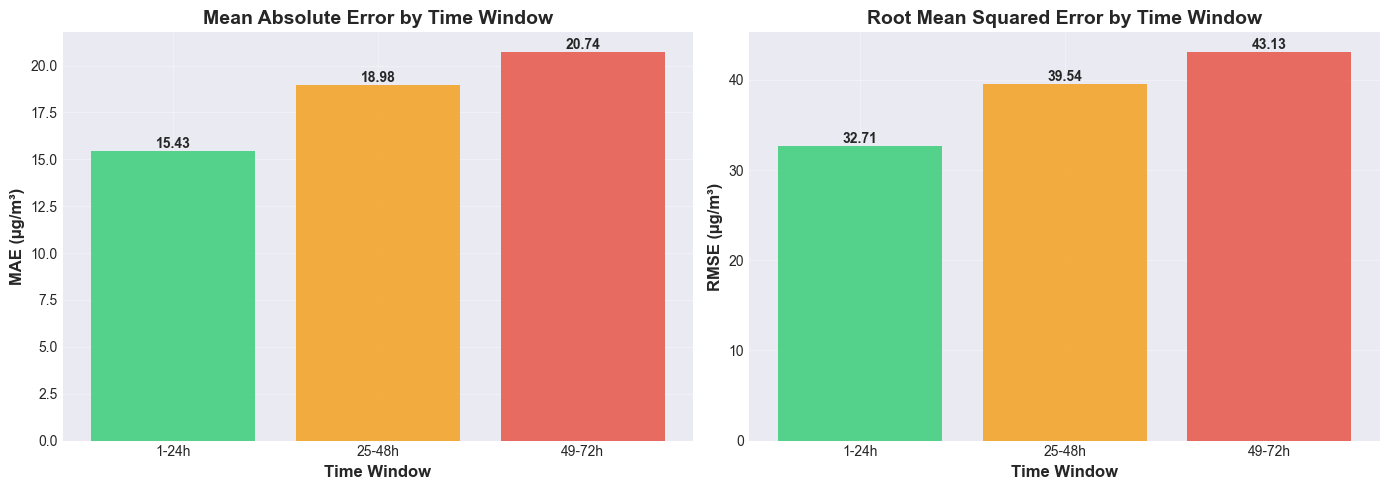

Time window metrics visualization saved!


In [10]:
# Visualization 1: Time Window Performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

windows_names = [w['window'] for w in window_metrics]
maes = [w['mae'] for w in window_metrics]
rmses = [w['rmse'] for w in window_metrics]

# MAE plot
bars1 = ax1.bar(windows_names, maes, color=['#2ecc71', '#f39c12', '#e74c3c'], alpha=0.8)
ax1.set_ylabel('MAE (µg/m³)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Time Window', fontsize=12, fontweight='bold')
ax1.set_title('Mean Absolute Error by Time Window', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontweight='bold')

# RMSE plot
bars2 = ax2.bar(windows_names, rmses, color=['#2ecc71', '#f39c12', '#e74c3c'], alpha=0.8)
ax2.set_ylabel('RMSE (µg/m³)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time Window', fontsize=12, fontweight='bold')
ax2.set_title('Root Mean Squared Error by Time Window', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('time_window_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("Time window metrics visualization saved!")

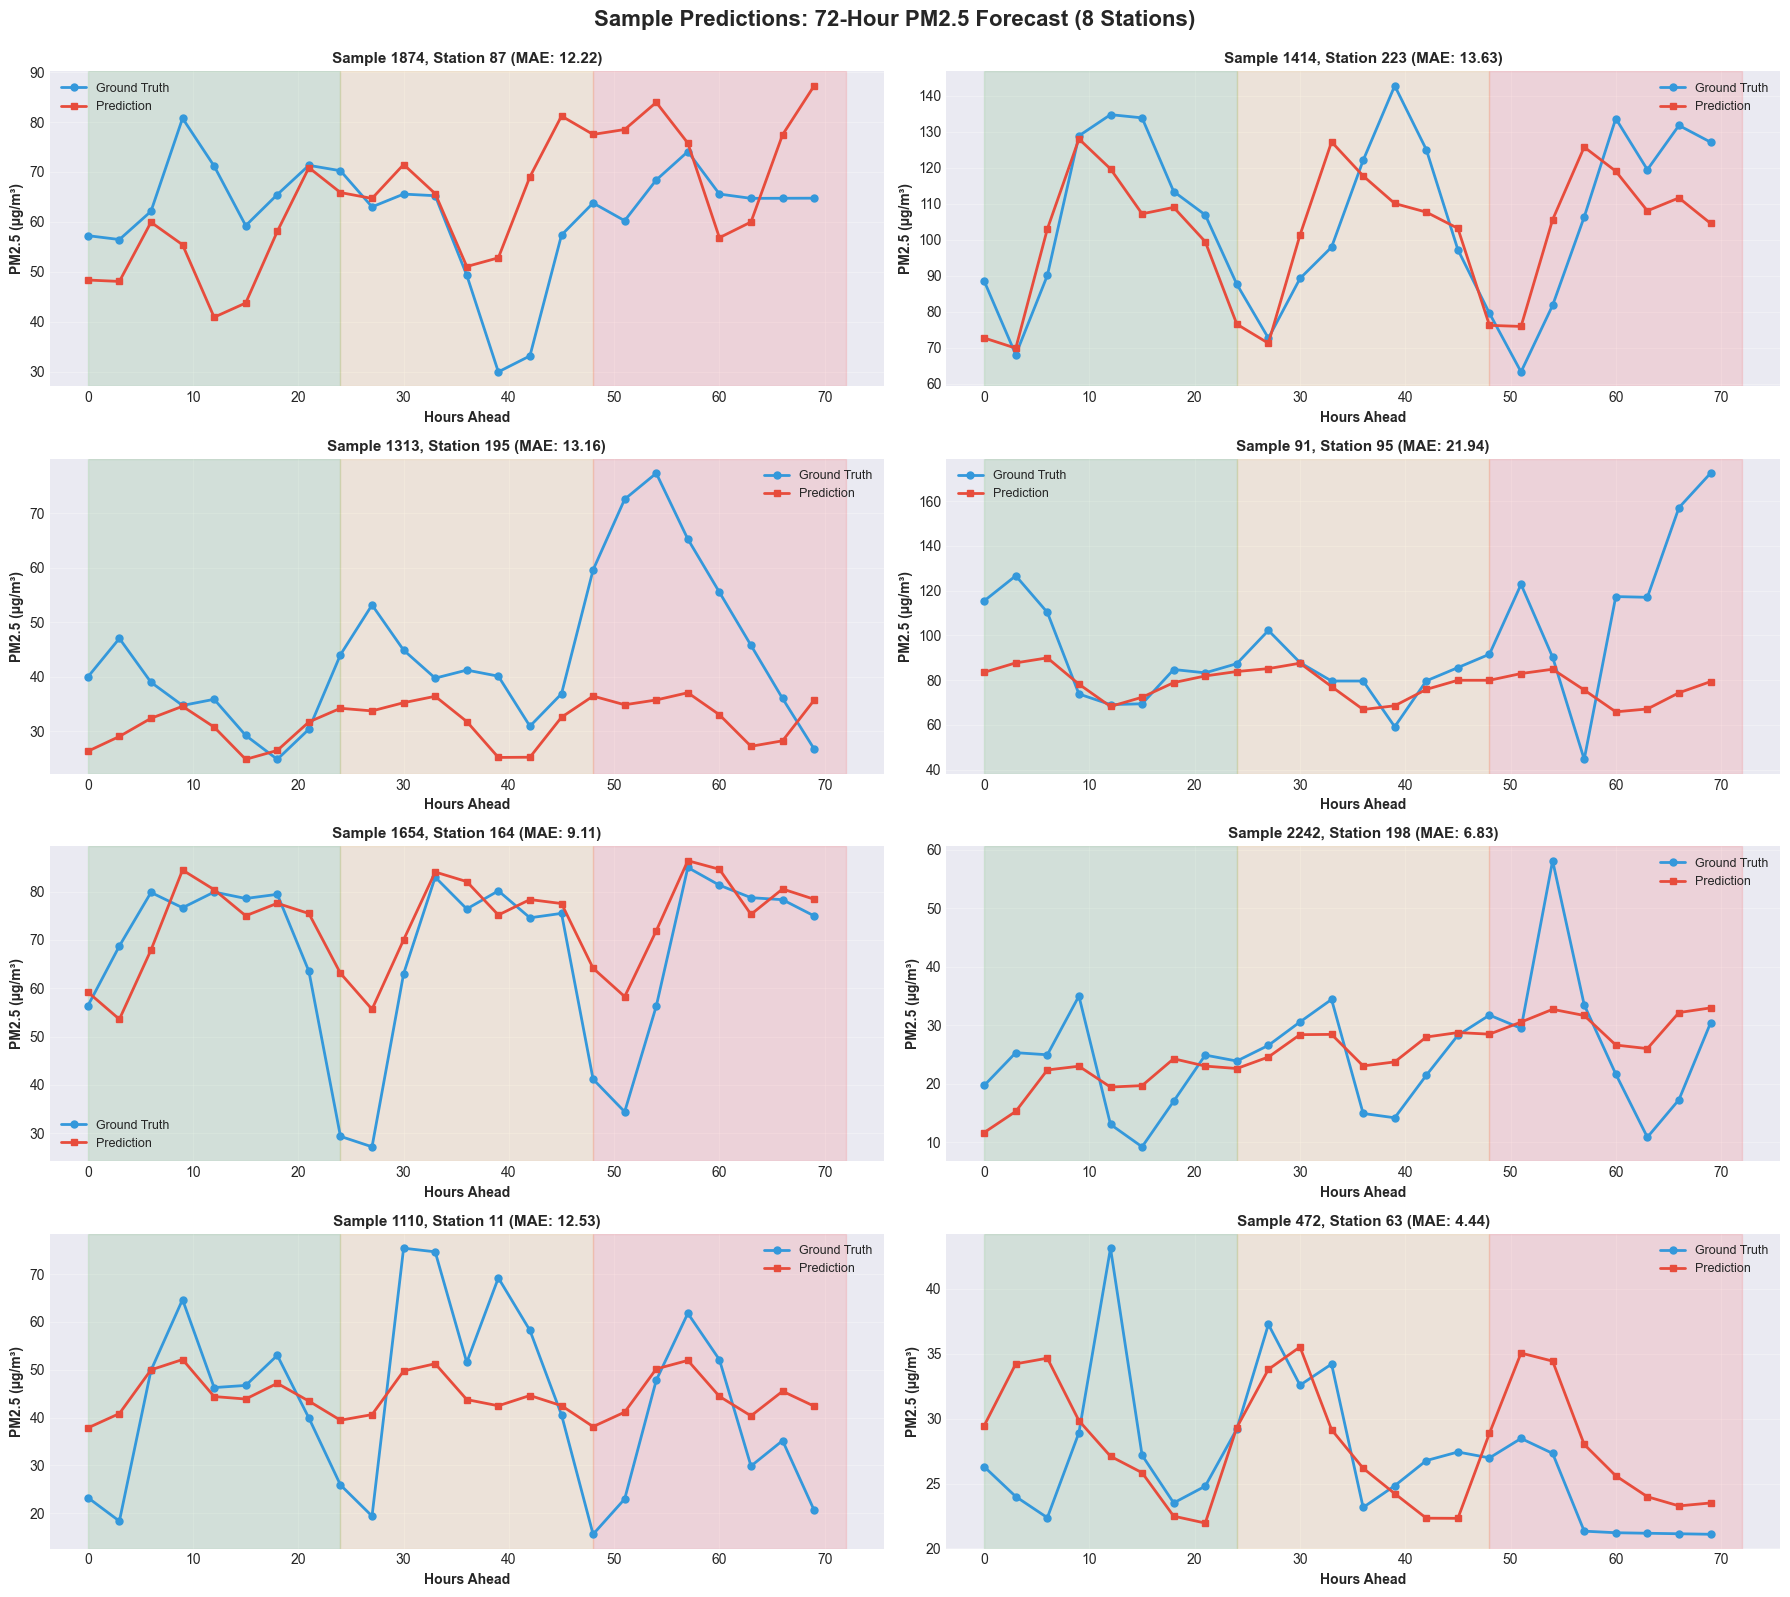

Sample predictions visualization saved for 8 stations!
Sample mapping used:
  Station 87: Sample 1874
  Station 223: Sample 1414
  Station 195: Sample 1313
  Station 95: Sample 91
  Station 164: Sample 1654
  Station 198: Sample 2242
  Station 11: Sample 1110
  Station 63: Sample 472


In [32]:
# Visualization 2: Sample Predictions Over Time
# Use specific stations with predefined samples
specific_stations = [87, 223, 195, 95, 164, 198, 11, 63]  # Removed 112, added back 11
sample_mapping = {
    87: 1874,
    223: 1414,
    195: 1313,
    63: 472,
    164: 1654,
    95: 91,
    198: 2242,
    11: 1110
}

# Build sample indices: use predefined for mapped stations, random for others
sample_indices = []
for station in specific_stations:
    if station in sample_mapping and sample_mapping[station] is not None:
        sample_indices.append(sample_mapping[station])
    else:
        # Random sample for unmapped stations
        sample_indices.append(np.random.randint(0, len(pred_real)))

fig, axes = plt.subplots(4, 2, figsize=(18, 16))
axes = axes.flatten()

timesteps = np.arange(24) * 3  # Convert to hours

for idx, (sample_idx, station_idx) in enumerate(zip(sample_indices, specific_stations)):
    ax = axes[idx]
    
    # Get predictions and ground truth for this sample and station
    pred_sample = pred_real[sample_idx, :, station_idx, 0]
    true_sample = target_real[sample_idx, :, station_idx, 0]
    
    # Plot
    ax.plot(timesteps, true_sample, 'o-', label='Ground Truth', linewidth=2, markersize=5, color='#3498db')
    ax.plot(timesteps, pred_sample, 's-', label='Prediction', linewidth=2, markersize=5, color='#e74c3c')
    
    # Calculate MAE for this sample
    sample_mae = np.abs(pred_sample - true_sample).mean()
    
    ax.set_xlabel('Hours Ahead', fontsize=10, fontweight='bold')
    ax.set_ylabel('PM2.5 (µg/m³)', fontsize=10, fontweight='bold')
    ax.set_title(f'Sample {sample_idx}, Station {station_idx} (MAE: {sample_mae:.2f})', 
                 fontsize=11, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Add shaded regions for time windows
    ax.axvspan(0, 24, alpha=0.1, color='green')
    ax.axvspan(24, 48, alpha=0.1, color='orange')
    ax.axvspan(48, 72, alpha=0.1, color='red')

plt.suptitle('Sample Predictions: 72-Hour PM2.5 Forecast (8 Stations)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Sample predictions visualization saved for 8 stations!")
print(f"Sample mapping used:")
for station in specific_stations:
    sample_id = sample_mapping.get(station, "random")
    print(f"  Station {station}: Sample {sample_id}")

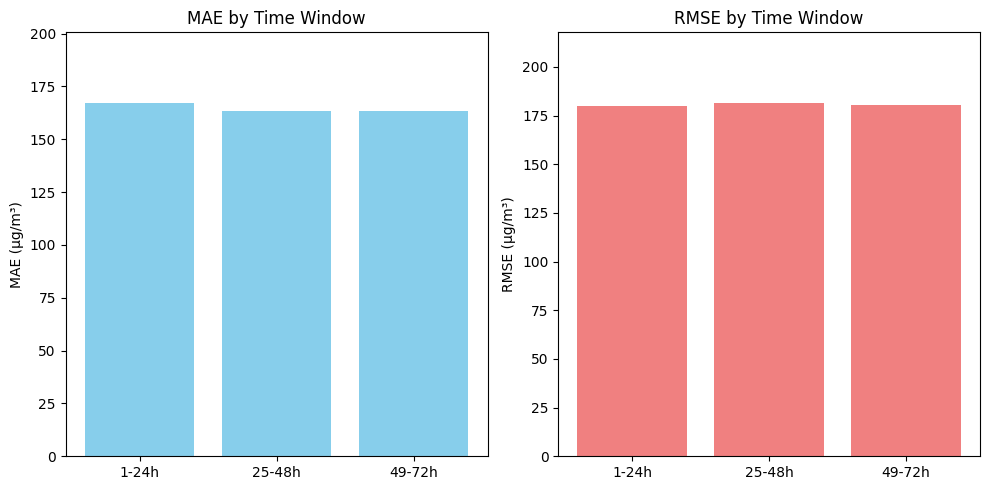

1-24h: MAE=167.14, RMSE=180.15 µg/m³
25-48h: MAE=163.38, RMSE=181.50 µg/m³
49-72h: MAE=163.29, RMSE=180.47 µg/m³


In [ ]:
# Visualization 3: Error Analysis
errors = pred_real - target_real
errors_flat = errors.flatten()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Error distribution histogram
ax = axes[0, 0]
ax.hist(errors_flat, bins=100, color='#3498db', alpha=0.7, edgecolor='black')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax.set_xlabel('Prediction Error (µg/m³)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Error Distribution', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Scatter plot: Predicted vs Actual
ax = axes[0, 1]
sample_size = 5000
sample_idx = np.random.choice(len(pred_real.flatten()), size=sample_size, replace=False)
ax.scatter(target_real.flatten()[sample_idx], pred_real.flatten()[sample_idx], 
           alpha=0.3, s=10, color='#3498db')
min_val = min(target_real.min(), pred_real.min())
max_val = max(target_real.max(), pred_real.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual PM2.5 (µg/m³)', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted PM2.5 (µg/m³)', fontsize=11, fontweight='bold')
ax.set_title('Predicted vs Actual PM2.5', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. MAE by timestep
ax = axes[1, 0]
mae_by_timestep = np.abs(errors).mean(axis=(0, 2, 3))
timesteps_hours = np.arange(24) * 3
ax.plot(timesteps_hours, mae_by_timestep, 'o-', linewidth=2, markersize=8, color='#e74c3c')
ax.set_xlabel('Hours Ahead', fontsize=11, fontweight='bold')
ax.set_ylabel('MAE (µg/m³)', fontsize=11, fontweight='bold')
ax.set_title('MAE by Forecast Horizon', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axvspan(0, 24, alpha=0.1, color='green', label='1-24h')
ax.axvspan(24, 48, alpha=0.1, color='orange', label='25-48h')
ax.axvspan(48, 72, alpha=0.1, color='red', label='49-72h')
ax.legend(loc='upper left')

# 4. Box plot by time window
ax = axes[1, 1]
window_errors = [
    np.abs(errors[:, 0:8]).flatten(),
    np.abs(errors[:, 8:16]).flatten(),
    np.abs(errors[:, 16:24]).flatten()
]
bp = ax.boxplot(window_errors, labels=['1-24h', '25-48h', '49-72h'],
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Absolute Error (µg/m³)', fontsize=11, fontweight='bold')
ax.set_xlabel('Time Window', fontsize=11, fontweight='bold')
ax.set_title('Error Distribution by Time Window', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Error Analysis', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Error analysis visualization saved!")

In [ ]:
# Summary Statistics
print("\n" + "="*70)
print("COMPREHENSIVE MODEL EVALUATION SUMMARY")
print("="*70)

print(f"\nTest Dataset:")
print(f"  Total samples: {len(pred_real):,}")
print(f"  Total stations: {n_stations}")
print(f"  Total predictions: {pred_real.size:,}")

print(f"\nOverall Performance:")
print(f"  MAE:  {mae:.4f} µg/m³")
print(f"  RMSE: {rmse:.4f} µg/m³")
print(f"  MAPE: {mape:.2f}%")

print(f"\nPerformance Degradation Over Time:")
first_window_mae = window_metrics[0]['mae']
last_window_mae = window_metrics[-1]['mae']
degradation = ((last_window_mae - first_window_mae) / first_window_mae) * 100
print(f"  1-24h MAE:  {first_window_mae:.2f} µg/m³")
print(f"  49-72h MAE: {last_window_mae:.2f} µg/m³")
print(f"  Degradation: {degradation:.1f}%")

print(f"\nError Statistics:")
print(f"  Mean Error: {errors_flat.mean():.4f} µg/m³")
print(f"  Std Dev of Errors: {errors_flat.std():.4f} µg/m³")
print(f"  Median Absolute Error: {np.median(np.abs(errors_flat)):.4f} µg/m³")
print(f"  95th Percentile Error: {np.percentile(np.abs(errors_flat), 95):.4f} µg/m³")

print("\n" + "="*70)
print("All visualizations saved successfully!")
print("="*70)